In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import time
import random
import requests
from urllib.parse import quote
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
import matplotlib.ticker as mtick

In [2]:
FIGURE_DIR = Path("../reports/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
animals_full = pd.read_csv(
    "../data/processed/animals_full.csv"
)
animals_full

,page_title,date,pageviews,animal,animal_class,image_count
0,Eastern_bent-wing_bat,20250101,2,Eastern bent-wing bat,Mammal,3
1,Eastern_bent-wing_bat,20250102,0,Eastern bent-wing bat,Mammal,3
2,Eastern_bent-wing_bat,20250103,0,Eastern bent-wing bat,Mammal,3
3,Eastern_bent-wing_bat,20250104,0,Eastern bent-wing bat,Mammal,3
4,Eastern_bent-wing_bat,20250105,3,Eastern bent-wing bat,Mammal,3
...,...,...,...,...,...,...
166509,Leptobrachella_aerea,20251227,2,Leptobrachella aerea,Amphibian,2
166510,Leptobrachella_aerea,20251228,1,Leptobrachella aerea,Amphibian,2
166511,Leptobrachella_aerea,20251229,2,Leptobrachella aerea,Amphibian,2
166512,Leptobrachella_aerea,20251230,2,Leptobrachella aerea,Amphibian,2


In [4]:
animal_totals = (
    animals_full
    .groupby(["page_title", "animal", "animal_class", "image_count"], as_index=False)["pageviews"]
    .sum()
    .rename(columns={"pageviews": "total_pageviews"})
)


animal_totals.sort_values(
    by = "total_pageviews",
    ascending = False
)

,page_title,animal,animal_class,image_count,total_pageviews
246,Mahi-mahi,Mahi-mahi,Fish,25,430825
400,Siamese_fighting_fish,Siamese fighting fish,Fish,16,328238
481,Wild_turkey,Wild turkey,Bird,26,265691
114,Common_ostrich,Common ostrich,Bird,52,252410
472,Western_capercaillie,Western capercaillie,Bird,29,169433
...,...,...,...,...,...
259,Marmorerpeton_wakei,Marmorerpeton wakei,Amphibian,0,35
25,Amphisbaena_heterozonata,Amphisbaena heterozonata,Reptile,0,33
176,Guarocuyus_jaraguanus,Guarocuyus jaraguanus,Reptile,0,28
234,Liaoning_salamander,Liaoning salamander,Amphibian,0,19


In [5]:
class_summary = (
    animal_totals
    .groupby("animal_class")["total_pageviews"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("median", ascending=False)
)

class_summary.sort_values(
    by = "mean",
    ascending = False
)

,count,mean,median,std
animal_class,,,,
Fish,100,18291.310000,676.5,59788.441650
Bird,100,11828.660000,1607.0,40615.712999
Reptile,100,6830.570000,1313.0,14758.736246
Amphibian,96,2394.645833,279.0,10311.887506
Mammal,96,2175.520833,789.0,4006.659220


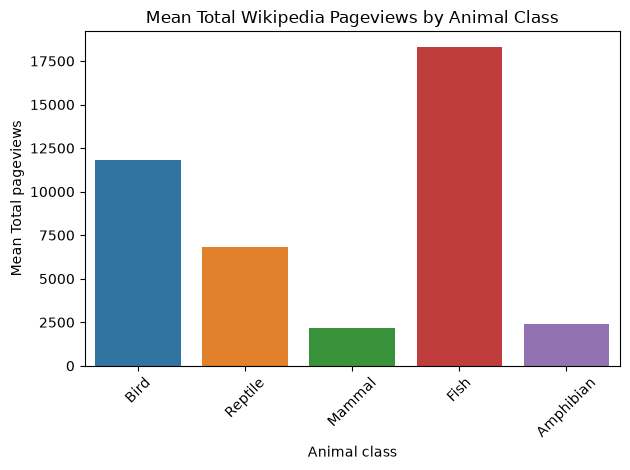

In [6]:
sns.barplot(
    data=class_summary,
    x="animal_class",
    y="mean",
    hue = "animal_class"
)

plt.title("Mean Total Wikipedia Pageviews by Animal Class")
plt.xlabel("Animal class")
plt.ylabel("Mean Total pageviews")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "mean_pageviews_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
# Correlation between image_count and pageviews
animal_totals[
    ["image_count", "total_pageviews"]
].corr(method="spearman")

,image_count,total_pageviews
image_count,1.000000,0.754809
total_pageviews,0.754809,1.000000


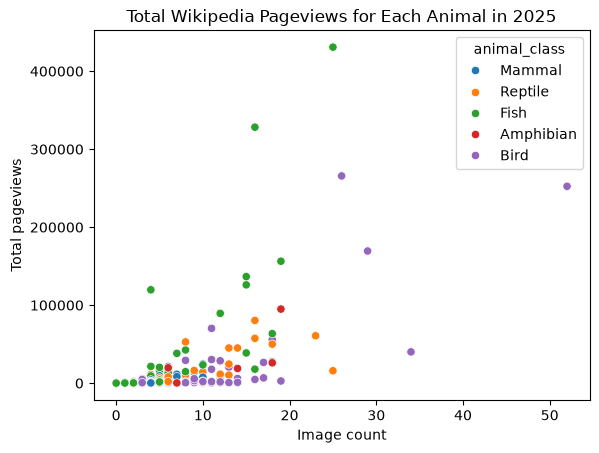

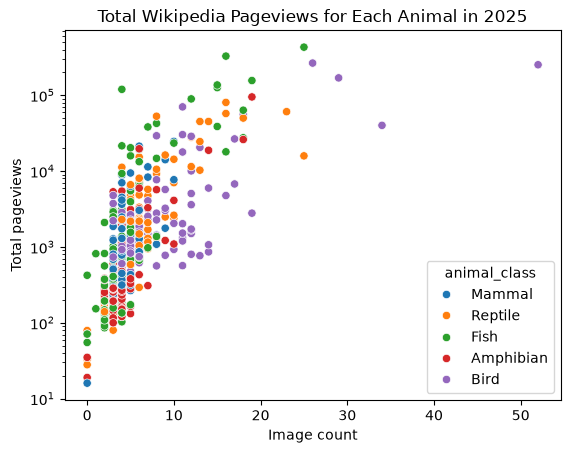

In [8]:
# Plotting all the animals, with image count as the x axis
sns.scatterplot(
    data=animal_totals,
    x="image_count",
    y="total_pageviews",
    hue="animal_class"
)

plt.title("Total Wikipedia Pageviews for Each Animal in 2025")
plt.xlabel("Image count")
plt.ylabel("Total pageviews")
plt.show()

sns.scatterplot(
    data=animal_totals,
    x="image_count",
    y="total_pageviews",
    hue="animal_class"
)

plt.title("Total Wikipedia Pageviews for Each Animal in 2025")
plt.xlabel("Image count")
plt.ylabel("Total pageviews")
plt.yscale("log")

plt.savefig(
    FIGURE_DIR / "images_vs_pageviews_log.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
# Can I get it to predict which class the animal is based on its view history

In [10]:
animals_full["date"] = pd.to_datetime(
    animals_full["date"].astype("int64")
    .astype(str)
    .str.zfill(8),
    format="%Y%m%d"
)

view_history = animals_full.pivot_table(
    index="page_title",
    columns="date",
    values="pageviews",
    aggfunc="sum",
    fill_value=0
)

view_history.head()

date,2025-01-01,2025-01-02,2025-01-03,2025-01-04,2025-01-05,2025-01-06,2025-01-07,2025-01-08,2025-01-09,2025-01-10,...,2025-12-22,2025-12-23,2025-12-24,2025-12-25,2025-12-26,2025-12-27,2025-12-28,2025-12-29,2025-12-30,2025-12-31
page_title,,,,,,,,,,,,,,,,,,,,,
Admiralty_flying_fox,2,3,3,1,1,1,1,2,2,0,...,0,3,1,1,0,2,1,0,2,1
African_sheath-tailed_bat,0,4,2,3,3,3,4,4,4,5,...,3,3,4,1,3,4,2,6,3,4
Agricola's_gracile_opossum,1,2,3,3,1,1,0,3,2,2,...,2,0,2,0,6,1,4,1,6,4
Alabama_map_turtle,2,3,5,5,5,4,1,6,3,3,...,2,3,7,1,3,0,3,2,1,2
Alabama_red-bellied_cooter,8,4,11,8,8,9,8,8,5,3,...,2,1,3,1,5,1,11,5,2,3


In [11]:
view_history.columns = [
    f"views_{date:%Y_%m_%d}"
    for date in view_history.columns
]
view_history.head()

,views_2025_01_01,views_2025_01_02,views_2025_01_03,views_2025_01_04,views_2025_01_05,views_2025_01_06,views_2025_01_07,views_2025_01_08,views_2025_01_09,views_2025_01_10,...,views_2025_12_22,views_2025_12_23,views_2025_12_24,views_2025_12_25,views_2025_12_26,views_2025_12_27,views_2025_12_28,views_2025_12_29,views_2025_12_30,views_2025_12_31
page_title,,,,,,,,,,,,,,,,,,,,,
Admiralty_flying_fox,2,3,3,1,1,1,1,2,2,0,...,0,3,1,1,0,2,1,0,2,1
African_sheath-tailed_bat,0,4,2,3,3,3,4,4,4,5,...,3,3,4,1,3,4,2,6,3,4
Agricola's_gracile_opossum,1,2,3,3,1,1,0,3,2,2,...,2,0,2,0,6,1,4,1,6,4
Alabama_map_turtle,2,3,5,5,5,4,1,6,3,3,...,2,3,7,1,3,0,3,2,1,2
Alabama_red-bellied_cooter,8,4,11,8,8,9,8,8,5,3,...,2,1,3,1,5,1,11,5,2,3


In [12]:
animal_metadata = (
    animals_full
    .groupby("page_title", as_index=True)
    .agg(
        animal_class=("animal_class", "first"),
        image_count=("image_count", "first")
    )
)
animal_metadata

,animal_class,image_count
page_title,,
Admiralty_flying_fox,Mammal,4
African_sheath-tailed_bat,Mammal,5
Agricola's_gracile_opossum,Mammal,6
Alabama_map_turtle,Reptile,6
Alabama_red-bellied_cooter,Reptile,9
...,...,...
Yellow-footed_tortoise,Reptile,9
Yungas_guan,Bird,3
Yunnan_box_turtle,Reptile,5


In [13]:
model_data = view_history.join(
    animal_metadata,
    how="inner"
).reset_index()

model_data.head()

,page_title,views_2025_01_01,views_2025_01_02,views_2025_01_03,views_2025_01_04,views_2025_01_05,views_2025_01_06,views_2025_01_07,views_2025_01_08,views_2025_01_09,...,views_2025_12_24,views_2025_12_25,views_2025_12_26,views_2025_12_27,views_2025_12_28,views_2025_12_29,views_2025_12_30,views_2025_12_31,animal_class,image_count
0,Admiralty_flying_fox,2,3,3,1,1,1,1,2,2,...,1,1,0,2,1,0,2,1,Mammal,4
1,African_sheath-tailed_bat,0,4,2,3,3,3,4,4,4,...,4,1,3,4,2,6,3,4,Mammal,5
2,Agricola's_gracile_opossum,1,2,3,3,1,1,0,3,2,...,2,0,6,1,4,1,6,4,Mammal,6
3,Alabama_map_turtle,2,3,5,5,5,4,1,6,3,...,7,1,3,0,3,2,1,2,Reptile,6
4,Alabama_red-bellied_cooter,8,4,11,8,8,9,8,8,5,...,3,1,5,1,11,5,2,3,Reptile,9


In [14]:
# Checking for duplicates
print(model_data["page_title"].duplicated().sum())

0


In [15]:

X = model_data.drop(
    columns=["page_title", "animal_class", "image_count"]
)
X = np.log1p(X)


y = model_data["animal_class"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [17]:
model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

Accuracy: 0.6767676767676768
Balanced accuracy: 0.6778947368421052
              precision    recall  f1-score   support

   Amphibian       0.68      0.75      0.71        20
        Bird       0.64      0.80      0.71        20
        Fish       0.78      0.35      0.48        20
      Mammal       0.62      0.79      0.70        19
     Reptile       0.74      0.70      0.72        20

    accuracy                           0.68        99
   macro avg       0.69      0.68      0.66        99
weighted avg       0.69      0.68      0.66        99



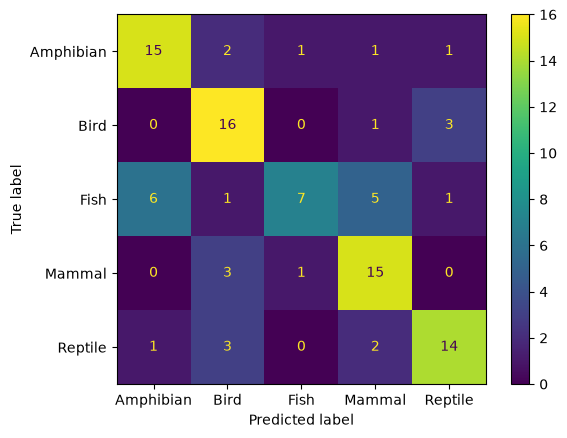

In [18]:
# Measuring the fit


predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print(
    "Balanced accuracy:",
    balanced_accuracy_score(y_test, predictions)
)

print(classification_report(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

plt.savefig(
    FIGURE_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

In [19]:
# Strangely low recall for fish but high (or average) precision --
# Meaning a lot of fish got classified as other classes but only fish were classified as fish
# Fish are hard to identify this way, except when they're obvious

In [20]:
# Testing against random guessing


baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)

print(
    "Baseline accuracy:",
    accuracy_score(y_test, baseline_predictions)
)

Baseline accuracy: 0.20202020202020202


In [21]:
# Let's see if the patterns that make this possible are immeadietly visible

In [22]:
sample_size = 5

In [23]:
# Take 10 of each class at random
sampled_animals = (
    animals_full[
        ["page_title", "animal_class"]
    ]
    .drop_duplicates()
    .groupby(
        "animal_class",
        group_keys=False
    )
    .sample(
        n=sample_size,
        random_state=42
    )
)

sampled_animals

,page_title,animal_class
161172,Kurdistan_newt,Amphibian
160226,Engystomops_freibergi,Amphibian
158988,Ptychadena_stenocephala,Amphibian
165937,Ptychadena_boettgeri,Amphibian
146288,Ptychadena_oxyrhynchus,Amphibian
95626,Rivoli's_hummingbird,Bird
80384,White-crested_guan,Bird
90555,Black-billed_brushturkey,Bird
86544,Black-eared_wood_quail,Bird
72391,Purple-crowned_plovercrest,Bird


In [24]:
time_plot_data = animals_full.merge(
    sampled_animals,
    on=["page_title", "animal_class"],
    how="inner"
).merge(
    animal_totals[
        ["page_title", "total_pageviews"]
        ],
    on=["page_title"],
    how="left"
)

time_plot_data["view_percent"] = (
    time_plot_data["pageviews"]
    / time_plot_data["total_pageviews"]
)


time_plot_data

,page_title,date,pageviews,animal,animal_class,image_count,total_pageviews,view_percent
0,Miniopterus_newtoni,2025-01-01,0,Miniopterus newtoni,Mammal,3,247,0.000000
1,Miniopterus_newtoni,2025-01-02,2,Miniopterus newtoni,Mammal,3,247,0.008097
2,Miniopterus_newtoni,2025-01-04,2,Miniopterus newtoni,Mammal,3,247,0.008097
3,Miniopterus_newtoni,2025-01-05,1,Miniopterus newtoni,Mammal,3,247,0.004049
4,Miniopterus_newtoni,2025-01-06,0,Miniopterus newtoni,Mammal,3,247,0.000000
...,...,...,...,...,...,...,...,...
8347,Ptychadena_boettgeri,2025-12-24,0,Ptychadena boettgeri,Amphibian,3,145,0.000000
8348,Ptychadena_boettgeri,2025-12-25,1,Ptychadena boettgeri,Amphibian,3,145,0.006897
8349,Ptychadena_boettgeri,2025-12-28,2,Ptychadena boettgeri,Amphibian,3,145,0.013793
8350,Ptychadena_boettgeri,2025-12-29,1,Ptychadena boettgeri,Amphibian,3,145,0.006897


In [25]:
# Rolling averages over 7 days will look better over a year
time_plot_data = time_plot_data.sort_values(
    ["page_title", "date"]
)

time_plot_data["seven_day_view_share"] = (
    time_plot_data
    .groupby("page_title")["view_percent"]
    .transform(
        lambda views: views.rolling(
            window=7,
            min_periods=1
        ).sum()
    )
)

time_plot_data.head()

,page_title,date,pageviews,animal,animal_class,image_count,total_pageviews,view_percent,seven_day_view_share
2121,Amphisbaena_cuiabana,2025-01-02,1,Amphisbaena cuiabana,Reptile,2,140,0.007143,0.007143
2122,Amphisbaena_cuiabana,2025-01-03,1,Amphisbaena cuiabana,Reptile,2,140,0.007143,0.014286
2123,Amphisbaena_cuiabana,2025-01-05,0,Amphisbaena cuiabana,Reptile,2,140,0.000000,0.014286
2124,Amphisbaena_cuiabana,2025-01-06,1,Amphisbaena cuiabana,Reptile,2,140,0.007143,0.021429
2125,Amphisbaena_cuiabana,2025-01-08,0,Amphisbaena cuiabana,Reptile,2,140,0.000000,0.021429


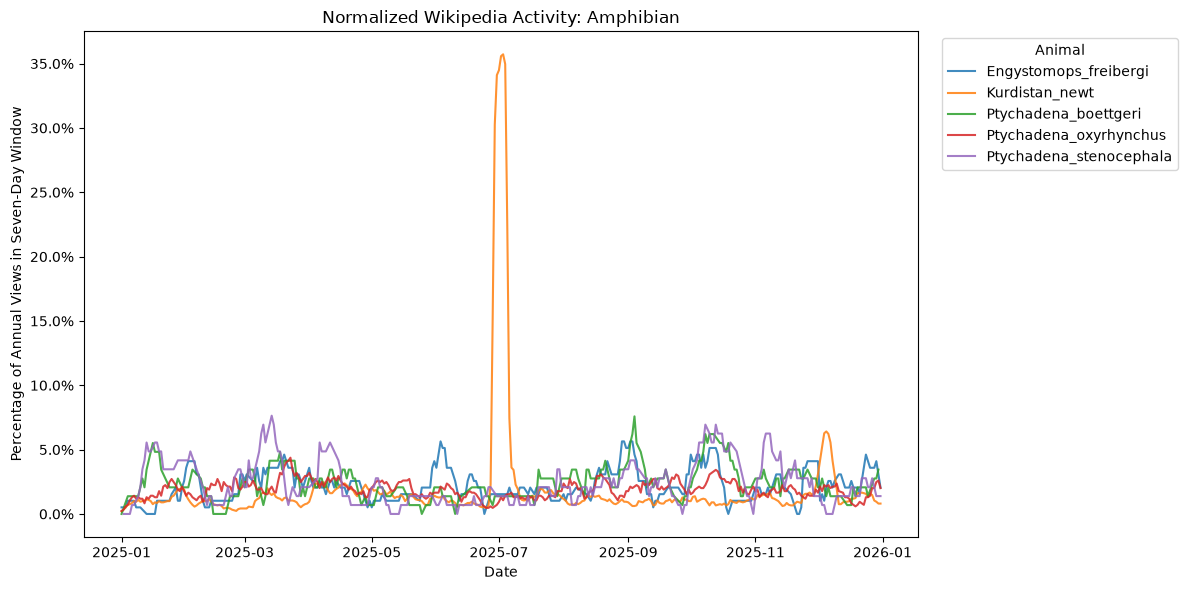

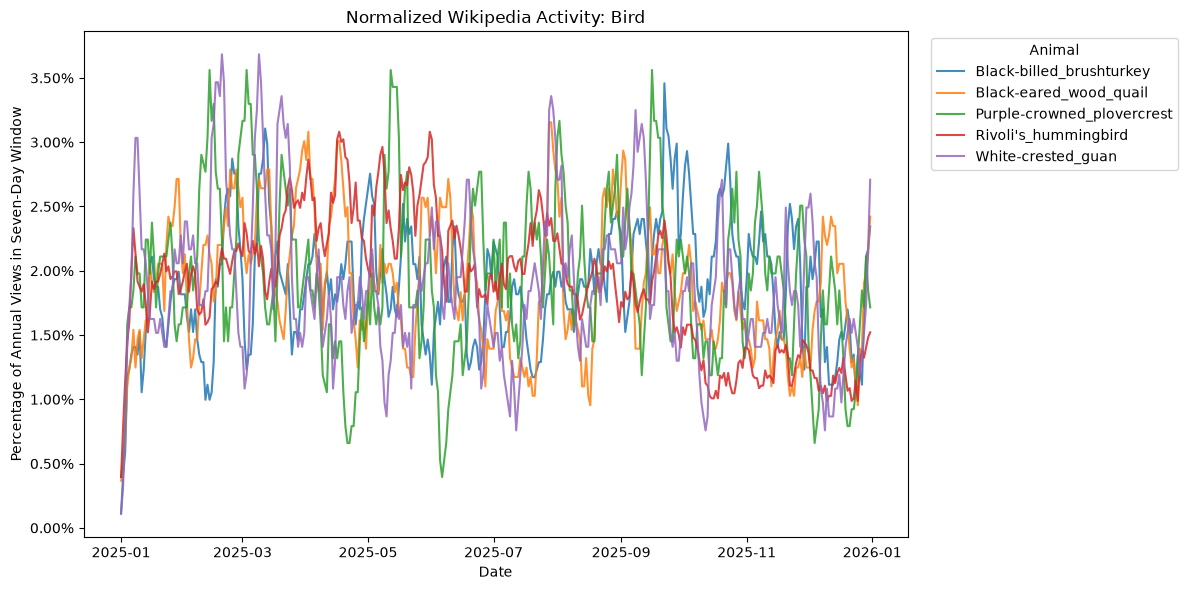

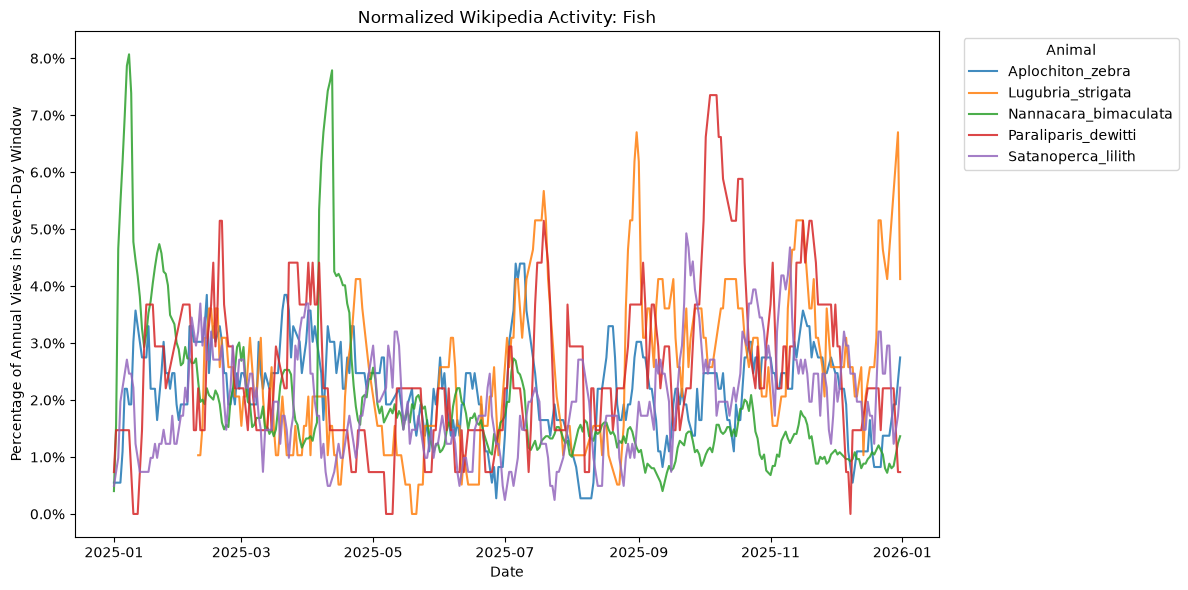

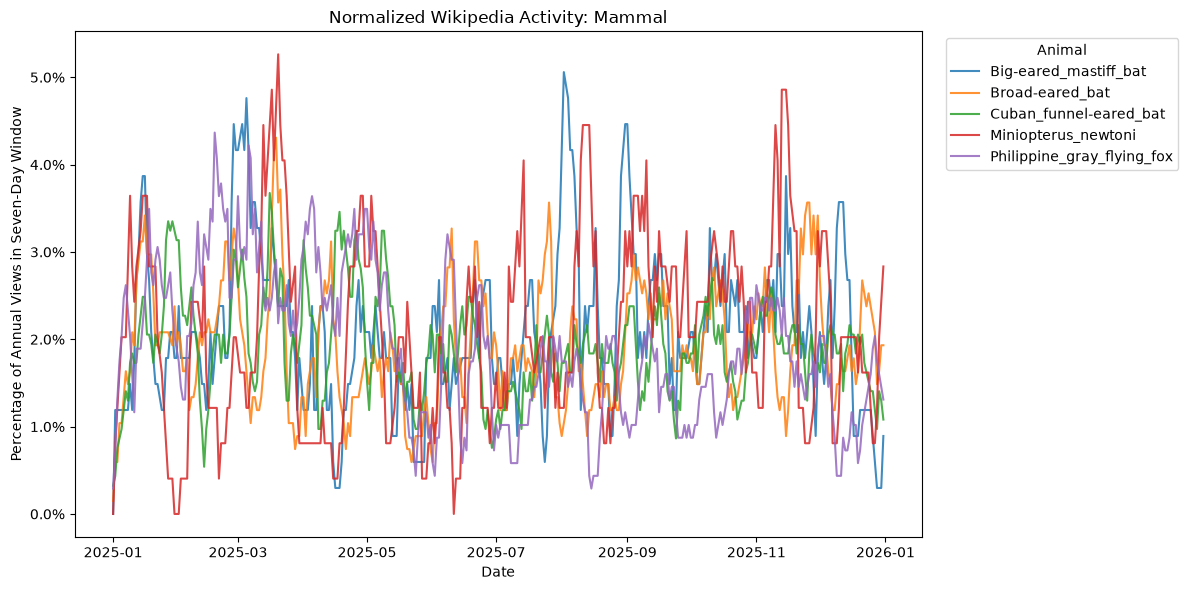

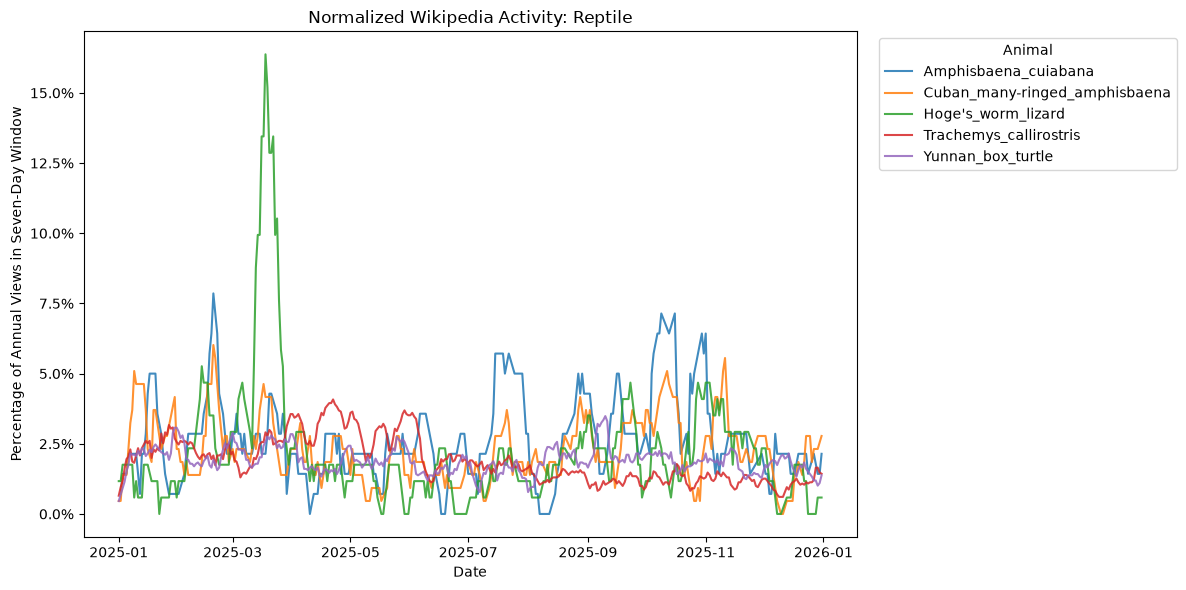

In [26]:
# Time plot for 1 year

for animal_class, class_data in time_plot_data.groupby(
    "animal_class"
):
    fig, ax = plt.subplots(figsize=(12, 6))

    sns.lineplot(
        data=class_data,
        x="date",
        y="seven_day_view_share",
        hue="page_title",
        estimator=None,
        errorbar=None,
        linewidth=1.5,
        alpha=0.85,
        ax=ax
    )

    ax.set_title(
        f"Normalized Wikipedia Activity: {animal_class}"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel(
        "Percentage of Annual Views in Seven-Day Window"
    )


    ax.yaxis.set_major_formatter(
        mtick.PercentFormatter(xmax=1)
    )

    ax.legend(
        title="Animal",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()

    filename = animal_class.lower().replace(" ", "_")

    plt.savefig(
        FIGURE_DIR / f"time_pattern_{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )
    
    plt.show()

In [27]:
# There are spikes that may appear at different times for different animals which must be why it works,
# The model detangles this noise to make predictions